In [1]:
%load_ext autoreload
%autoreload 2

from blochK import Hamiltonian2D
import blochK
from blochK.plotting import plot_FS, plot_bandstruc

import numpy as np
from numpy import pi,cos,sin,exp

import matplotlib.pyplot as plt
import matplotlib

from blochK.plotting.utils import extent #for getting the correct extent

# Defining the Haldane model

First, we define the Haldane model which consits of NN hoppings on the Honeycomb model, NNN imaginary hoppings and a sublattice potential.

In [2]:
n1 = np.array([ 0.5,np.sqrt(3)/2])
n2 = np.array([-0.5,np.sqrt(3)/2])

def Haldane_fct(kx,ky, t=1,t2=0, m=0, mu=0):
    """Defining the Haldane model."""
    Hk = np.zeros((2,2,*kx.shape), dtype=complex)

    kdotn1 = kx * n1[0] + ky * n1[1]
    kdotn2 = kx * n2[0] + ky * n2[1]
    f = 1 + np.exp(1j*kdotn1) + np.exp(1j*kdotn2)
    g = np.sin(kdotn1) - np.sin(kdotn2) + np.sin(kdotn2 - kdotn1)
    # NNN vectors (same-sublattice)
    b1 = n1 - n2
    b2 = -n1
    b3 = -n2
    kdotb1 = kx * b1[0] + ky * b1[1]
    kdotb2 = kx * b2[0] + ky * b2[1]
    kdotb3 = kx * b3[0] + ky * b3[1]
    dz0 = - mu
    dz  = m + 2.0 * t2 * (np.sin(kdotb1) + np.sin(kdotb2) + np.sin(kdotb3))


    Hk[0,0] = dz0 + dz
    Hk[1,1] = dz0 - dz
    Hk[0,1] = -t * f
    Hk = blochK.hamiltonian_fct.make_hermitian(Hk)
    
    return Hk

Haldane = Hamiltonian2D(Haldane_fct, n1=n1, n2=n2, basis=['sublattice'],basis_states=['A','B'])
Haldane.add_operator('sublattice',np.array([1,-1]))

Haldane.BZ.set_points({
    'K':  (Haldane.BZ.m1 + 2*Haldane.BZ.m2)/3,
    "K'": (2*Haldane.BZ.m1 + Haldane.BZ.m2)/3
})

The Bandstructure shows two inequivalent valleys.

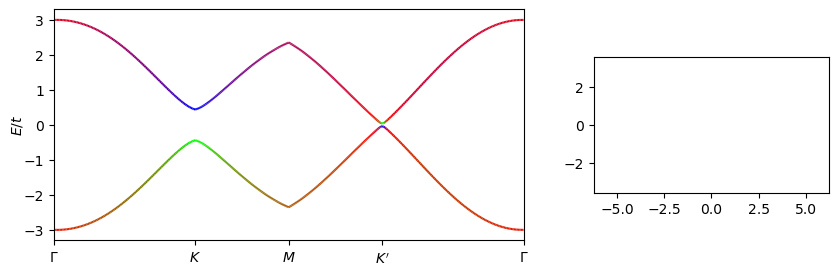

In [3]:
#Haldane model is topological for |t2|>m/sqrt(3)
Haldane.update_params(dict(t2=0.2/(3**0.5)*1.2,m=-0.2,mu=0))

#Haldane.update_params(dict(t2=1/(3**0.5)*0.8,m=1,mu=0))

fig, [ax,ax1] = plt.subplots(1,2,gridspec_kw={'width_ratios': [2,1]},figsize=(10,3))
labels = [r'\Gamma',"K",'M',"K'",r'\Gamma']
coloring_operator = Haldane.operator.sublattice

plot_bandstruc(ax,Haldane,labels_points_path=labels,coloring_operator=coloring_operator)
plot_FS(ax1,Haldane,coloring_operator=coloring_operator,kmesh='BZ')

## Computing topological quantities

The Berry curvature

$\Omega_{n; xy}(\vec{k}) = \mathrm{i} \left[ \left\langle \frac{\partial u_{n}}{\partial k_x}| \frac{\partial u_{n}}{\partial k_y} \right\rangle - \left\langle \frac{\partial u_{n}}{\partial k_y} \middle| \frac{\partial u_{n}}{\partial k_x} \right\rangle\right]$

Here it is evaluated using the Fukui–Hatsugai–Suzuki method, i.e. a numerically stable version where the flux through small plaquettes of the Brillouin zone is computed. 

In [4]:
import blochK.topology

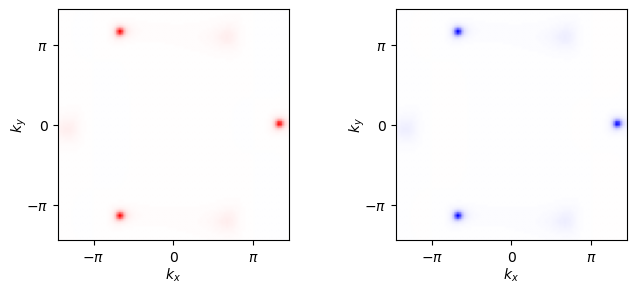

In [13]:
Lk = 101
ks = np.meshgrid(np.linspace(-4.6,4.6,Lk),np.linspace(-4.6,4.6,Lk),indexing='ij')
ks = np.array(ks)

#Berry curvature function returns the curvature and the kmesh which is trimmed of its edges
# If no kmesh is provided, it uses a the BZ of the Hamiltonian and the edges are not trimmed
berry_curvature,ks = blochK.topology.berry_curvature(Haldane,kmesh=ks) #shape=(nbands,Lk-2,Lk-2)


fig, axs = plt.subplots(1,2,figsize=(8,3))
vmax = np.max(np.abs(berry_curvature))
axs[0].imshow(berry_curvature[0].T,extent=extent(ks),origin='lower',cmap='bwr',vmin=-vmax,vmax=vmax)
axs[1].imshow(berry_curvature[1].T,extent=extent(ks),origin='lower',cmap='bwr',vmin=-vmax,vmax=vmax)

for ax in axs:
    ax.set_aspect('equal')
    ax.set_xlabel(r'$k_x$',labelpad=1)
    ax.set_xticks([-pi,0,pi])
    ax.set_xticklabels([r'$-\pi$',0,r'$\pi$'])
    ax.set_ylabel(r'$k_y$',labelpad=-2.5)
    ax.set_yticks([-pi,0,pi])
    ax.set_yticklabels([r'$-\pi$',0,r'$\pi$'])
    ax.set_xticks([-pi,0,pi])
    ax.set_yticks([-pi,0,pi])

The Chern number 

$C_n = \frac{1}{2\pi} \sum_{\vec{k}}  \Omega_{n; xy}(\vec{k})$

calls the method 'berry_curvature' internally with a k-mesh which is automatically the BZ. It requires a gap between the bands.

In [14]:
blochK.topology.chern_number(Haldane)

array([ 1., -1.])

## Anomalous Hall conductivity

The anomalous Hall conductivity is set by the Berry curvature below the Fermi energy

$\sigma_{xy} = \frac{e^2}{\hbar} \frac{1}{2\pi} \sum_{\vec{k}} n_F(\epsilon(\vec{k}))  \Omega_{n; xy}(\vec{k})$

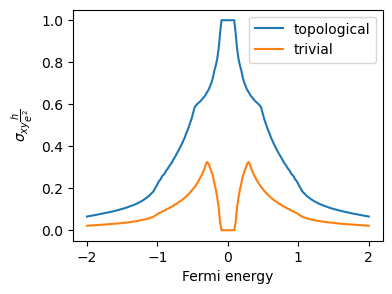

In [15]:
Lk = 100
energies = np.linspace(-2,2,200)

Haldane.update_params(dict(t2=0.2/(3**0.5)*1.5,m=0.2))
cond_topo = blochK.topology.conductivity_anomalous_Hall(Haldane,energy=energies,Lk=Lk)

Haldane.update_params(dict(t2=0.2/(3**0.5)*0.5,m=0.2))
cond_trivial = blochK.topology.conductivity_anomalous_Hall(Haldane,energy=energies,Lk=Lk)


fig, ax = plt.subplots(1,1,figsize=(4,3))
ax.plot(energies,cond_topo,label='topological')
ax.plot(energies,cond_trivial,label='trivial')

ax.set_xlabel('Fermi energy')
ax.set_ylabel(r'$\sigma_{xy} \frac{h}{e^2}$')
ax.legend()

In the topological phase the summed Berry curvature continously increases until it sums to 1, the Chern number of the lower band, when the Fermi energy is inside the gap. Inside the trivial phase inversion symmetry can also be broken ($K$ and $K'$ are not equivalent) such that at a given energy $\sigma_{xy} > 0$, because the Berry curvatures which compensate sit at different energies

## Multiband Berry flux

The anomalous Hall conductivity uses `berry_curvature_multiband_state` internally. The function computes the total Berry flux of the occupied subspace below a chosen Fermi energy and remains well defined when bands cross inside that subspace. It is also available directly when the momentum-resolved flux is needed.

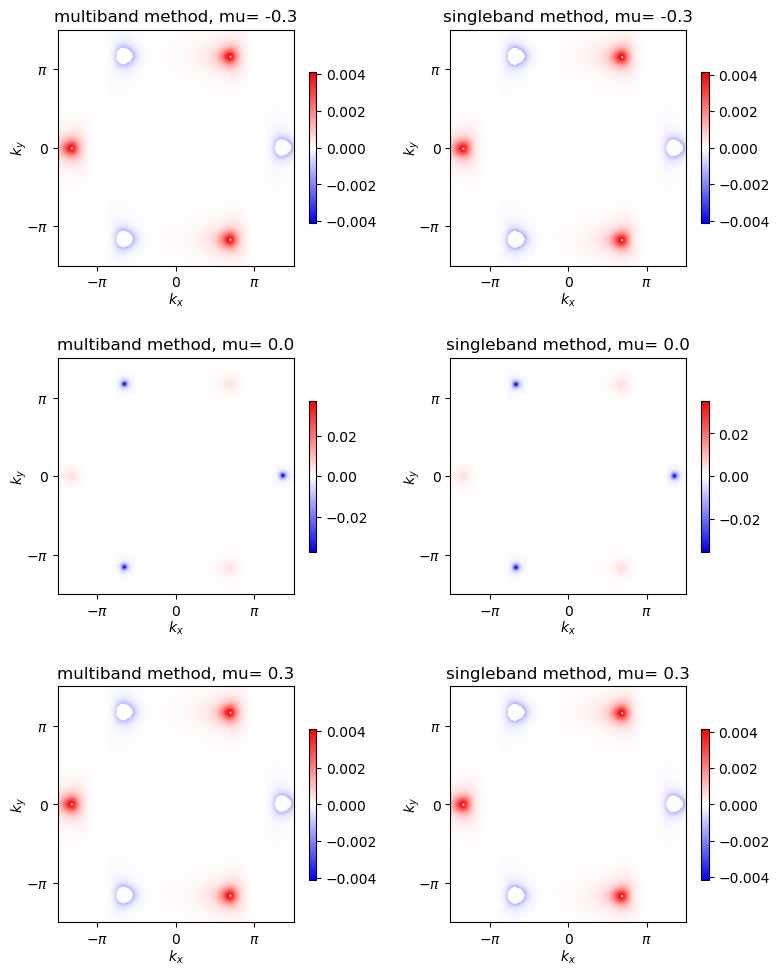

In [26]:
Haldane.update_params(dict(t2=0.2/(3**0.5)*0.5,m=0.2)) #chooose the trivial phase for the following comparison of the two methods

energy = np.array([-0.3,0,0.3])

ks = blochK.plotting.utils.sample_square(300)*1.5
#ks = Haldane.BZ.sample(Lk)

es,psis = Haldane.diagonalize(*ks)

f_multiband  = blochK.topology.methods.berry_curvature_multiband_state(es,psis,energy=energy)
f_singleband = blochK.topology.utils.berry_curvature_state(psis)

fig,axs = plt.subplots(3,2,figsize=(8,10))

for i in range(len(energy)):
    axs[i,0].set_title(f'multiband method, mu= {energy[i]:.1f}', fontsize=12)
    vmax = np.max(np.abs(f_multiband[i,1:-1,1:-1]))
    im = axs[i,0].imshow(f_multiband[i,1:-1,1:-1].T,extent=extent(ks),origin='lower',cmap='bwr',vmin=-vmax,vmax=vmax)
    cbar = fig.colorbar(im,ax=axs[i,0],shrink=0.6)

    axs[i,1].set_title(f'singleband method, mu= {energy[i]:.1f}', fontsize=12)
    f0 = (f_singleband*(es<energy[i])).sum(axis=0)
    vmax = np.max(np.abs(f0[1:-1,1:-1]))
    im = axs[i,1].imshow(f0[1:-1,1:-1].T,extent=extent(ks),origin='lower',cmap='bwr',vmin=-vmax,vmax=vmax)
    cbar = fig.colorbar(im,ax=axs[i,1],shrink=0.6)

for ax in axs.flatten():
    ax.set_aspect('equal')
    ax.set_xlabel(r'$k_x$',labelpad=1)
    ax.set_xticks([-pi,0,pi])
    ax.set_xticklabels([r'$-\pi$',0,r'$\pi$'])
    ax.set_ylabel(r'$k_y$',labelpad=-2.5)
    ax.set_yticks([-pi,0,pi])
    ax.set_yticklabels([r'$-\pi$',0,r'$\pi$'])
    ax.set_xticks([-pi,0,pi])
    ax.set_yticks([-pi,0,pi])

plt.tight_layout()




The method follows the local-Berry-phase construction of [Sawahata *et al.*, Phys. Rev. B **107**, 024404 (2023)](https://doi.org/10.1103/PhysRevB.107.024404), which extends the Fukui-Hatsugai-Suzuki determinant-link method to metals. It returns a **Berry flux per plaquette**, not a curvature density. Although the construction uses the non-Abelian connection of an occupied multiplet, the determinant extracts only its gauge-invariant trace; the full matrix-valued non-Abelian curvature is not returned.

For a fixed number $N$ of occupied bands, first form the overlap matrix between neighboring points,
\begin{equation}
M^{(N)}_{\mu,mn}(\mathbf{k}) = \langle u_m(\mathbf{k}) | u_n(\mathbf{k}+\Delta k_\mu) \rangle, \qquad m,n=1,\ldots,N.
\end{equation}

The phase of its determinant is a normalized $U(1)$ link variable for the entire occupied subspace,
\begin{equation}
U^{(N)}_\mu(\mathbf{k}) = \frac{\det M^{(N)}_\mu(\mathbf{k})}{|\det M^{(N)}_\mu(\mathbf{k})|}.
\end{equation}

Multiplying four links around an elementary plaquette removes the arbitrary local $U(N)$ choice of eigenvector frame. Its phase is the total Berry flux of the lowest $N$ bands,
\begin{equation}
F^{(N)}(\mathbf{k}) = \arg\left[U^{(N)}_x(\mathbf{k})U^{(N)}_y(\mathbf{k}+\Delta k_x)U^{(N)*}_x(\mathbf{k}+\Delta k_y)U^{(N)*}_y(\mathbf{k})\right].
\end{equation}

In a metal, the occupation $N_i=\sum_n \Theta(E_F-\epsilon_n(\mathbf{k}_i))$ can differ at the four corners. A determinant cannot be formed directly between subspaces of different dimensions. Instead, calculate four fixed-rank fluxes on the same plaquette, using each corner occupation $N_i$ in turn, and average them:
\begin{equation}
\overline{F}(\mathbf{k};E_F) \simeq \frac{1}{4}\sum_{i=1}^{4}F^{(N_i)}(\mathbf{k}).
\end{equation}

The optional band projection only discards bands that are never occupied for any requested Fermi energy. Finally, $\sum_{\mathbf{k}}\overline{F}/(2\pi)$ gives the occupied Chern number in a gap, or the intrinsic Hall conductivity in units of $e^2/h$ in a metal. The mesh must be periodic and fine enough that relevant overlap determinants are nonzero and no plaquette phase crosses the $\pm\pi$ branch cut; convergence should therefore be checked by increasing the mesh density.

Importantly note that this method requires the Hamiltonian to be formulated in the periodic gauge, \textbf{Bloch gauge}, embedding gauge, periodic Bloch basis or $\vec{k} \cdot \vec{R}_{\alpha}$-gauge (these are all different names for the same gauge) where the phase includes orbital position.

In [21]:
# Minimal comparison on a periodic Brillouin-zone mesh
Haldane.update_params(dict(t2=0.2 / np.sqrt(3) * 1.5, m=0.2, mu=0))
Lk = 51
fermi_energies = np.array([-1.0, 0.0, 1.0])

kmesh = Haldane.BZ.sample(Lk)
es, psis = Haldane.diagonalize(*kmesh)

# Gauge-invariant determinant-link result
flux_multiband = blochK.topology.berry_curvature_multiband_state(
    es, psis, energy=fermi_energies
)
sigma_multiband = flux_multiband.sum(axis=(1, 2)) / (2 * np.pi)

# Direct sum of separately computed band fluxes. This is suitable when
# individual bands are isolated, but is not gauge invariant at crossings.
flux_per_band = blochK.topology.utils.berry_curvature_state(psis)
occupied = es[None] < fermi_energies[:, None, None, None]
sigma_band_sum = (
    flux_per_band[None] * occupied
).sum(axis=(1, 2, 3)) / (2 * np.pi)

# The public transport wrapper uses the determinant-link routine internally.
sigma_wrapper = blochK.topology.conductivity_anomalous_Hall(
    Haldane, energy=fermi_energies, Lk=Lk
)

print(" E_F | determinant links | band-by-band | Hall wrapper")
for ef, sigma_det, sigma_band, sigma_api in zip(
    fermi_energies, sigma_multiband, sigma_band_sum, sigma_wrapper
):
    print(
        f"{ef:+4.1f} | {sigma_det:+17.8f} | "
        f"{sigma_band:+12.8f} | {sigma_api:+12.8f}"
    )

assert np.allclose(sigma_multiband, sigma_wrapper)

 E_F | determinant links | band-by-band | Hall wrapper
-1.0 |       +0.21883328 |  +0.21818047 |  +0.21883328
+0.0 |       +1.00000000 |  +1.00000000 |  +1.00000000
+1.0 |       +0.21883328 |  +0.21818047 |  +0.21883328
